##### F4 — K-means Cluster Analysis (Warehouse Placement, 4D)

##### Purpose

This notebook characterizes F4's cluster structure: 
the high-y region's spatial extent, the spread of low-y exploration points, and the cluster-level view of the regime.

##### Function: F4 — Warehouse Placement, 4D
- Domain: [0,1]⁴
- Y range: bounded but very wide (-32.6 to +0.74)
- Preprocessing for clustering: symlog10 (linthresh=1.0) — matches the pipeline's transform for wide-range y
- Known structure: single tight peak; sharp drops in 
  x3 and x4 directions; x1 has shallow local maximum just above anchor; GP says x2 is irrelevant

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load F4 data
data = np.load('F4_data.npz')
X = data['X']
y = data['y']

print(f"F4 dataset: {len(X)} points")
print(f"  y range: [{y.min():.4f}, {y.max():.4f}]")
print(f"  Positive y count: {(y > 0).sum()} / {len(y)}")
print(f"  Best:    X={X[y.argmax()]}, y={y.max():.4f}")
print(f"  Top 5 y values:")
for idx in np.argsort(y)[-5:][::-1]:
    print(f"    X={X[idx]}, y={y[idx]:+.4f}")

F4 dataset: 42 points
  y range: [-32.6257, 0.7420]
  Positive y count: 8 / 42
  Best:    X=[0.416895 0.415413 0.359164 0.412576], y=0.7420
  Top 5 y values:
    X=[0.416895 0.415413 0.359164 0.412576], y=+0.7420
    X=[0.4219 0.4154 0.3592 0.4126], y=+0.7282
    X=[0.416895 0.415413 0.369164 0.412576], y=+0.7165
    X=[0.416895 0.415413 0.359164 0.405   ], y=+0.7095
    X=[0.416895 0.415413 0.359164 0.392576], y=+0.6463


##### Step 1 — Symlog10 transformation

F4's y spans ~33 units (most heavily negative, with 7 of 41 points 
positive). For clustering visualization, we apply symlog10 with 
linthresh=1.0 to match the pipeline.

In [2]:
def symlog10(y, linthresh=1.0):
    """Symmetric log10 transform with linear region near zero."""
    sign = np.sign(y)
    abs_y = np.abs(y)
    return sign * np.where(abs_y > linthresh, 
                            np.log10(abs_y / linthresh) + 1, 
                            abs_y / linthresh)

y_transformed = symlog10(y)
print(f"Transformed y range: [{y_transformed.min():.3f}, {y_transformed.max():.3f}]")

Transformed y range: [-2.514, 0.742]


##### Step 2 — Silhouette analysis (k = 2 to 6)

F4 has 41 points, supporting more cluster candidates than smaller 
datasets. We test k = 2 through 6.

In [3]:
sil_scores = {}
for k in range(2, min(7, len(X))):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    sil_scores[k] = silhouette_score(X, km.labels_)
    print(f"  k={k}: silhouette = {sil_scores[k]:+.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n→ Natural cluster count: k = {best_k}")

  k=2: silhouette = +0.3126
  k=3: silhouette = +0.2957
  k=4: silhouette = +0.2947
  k=5: silhouette = +0.3044
  k=6: silhouette = +0.3180

→ Natural cluster count: k = 6


##### Step 3 — Cluster characterization at natural k

In [4]:
km = KMeans(n_clusters=best_k, n_init=20, random_state=42).fit(X)
labels = km.labels_

print(f"Cluster characterization (k={best_k}):")
print(f"{'cluster':>8} {'n':>4} {'mean_y':>10} {'max_y':>10} {'centroid':>40}")
print("  " + "-" * 80)

best_cluster = int(labels[y.argmax()])
for i in range(best_k):
    members = (labels == i)
    n = int(members.sum())
    mean_y = float(np.mean(y[members]))
    max_y = float(np.max(y[members]))
    centroid = km.cluster_centers_[i]
    marker = " ★" if i == best_cluster else ""
    centroid_str = "[" + ", ".join(f"{v:.3f}" for v in centroid) + "]"
    print(f"{i:>8} {n:>4} {mean_y:>+10.3f} {max_y:>+10.3f} {centroid_str}{marker}")

print(f"\n→ Current best belongs to cluster {best_cluster}")

Cluster characterization (k=6):
 cluster    n     mean_y      max_y                                 centroid
  --------------------------------------------------------------------------------
       0   19     -5.671     +0.742 [0.341, 0.454, 0.317, 0.290] ★
       1    6    -23.197    -12.742 [0.624, 0.761, 0.346, 0.837]
       2    5    -22.161    -13.123 [0.878, 0.594, 0.720, 0.630]
       3    6    -16.102    -13.528 [0.571, 0.168, 0.743, 0.274]
       4    2    -21.442    -16.026 [0.803, 0.838, 0.288, 0.152]
       5    4    -14.282    -11.700 [0.345, 0.077, 0.136, 0.625]

→ Current best belongs to cluster 0


##### Step 4 — High-y sub-region characterization

The current best [0.4169, 0.4154, 0.3592, 0.4126] sits in its cluster.
We characterize the spread of high-y points (y > 0.5) to understand 
the peak's spatial extent.

In [5]:
y_threshold = 0.5
high_y_mask = (labels == best_cluster) & (y > y_threshold)

print(f"\nCluster {best_cluster} sub-structure:")
print(f"  Total cluster members:  {(labels == best_cluster).sum()}")
print(f"  High-y sub-region (y > {y_threshold:.2f}): {high_y_mask.sum()}")

if high_y_mask.sum() > 0:
    X_high = X[high_y_mask]
    print(f"  High-y X ranges:")
    for dim_i in range(4):
        dim_lbl = f"x{dim_i+1}"
        print(f"    {dim_lbl}: [{X_high[:, dim_i].min():.3f}, {X_high[:, dim_i].max():.3f}], "
              f"spread = {np.ptp(X_high[:, dim_i]):.3f}")


Cluster 0 sub-structure:
  Total cluster members:  19
  High-y sub-region (y > 0.50): 7
  High-y X ranges:
    x1: [0.417, 0.422], spread = 0.005
    x2: [0.415, 0.415], spread = 0.000
    x3: [0.339, 0.369], spread = 0.030
    x4: [0.393, 0.433], spread = 0.040


##### Step 5 — PCA projection for 2D visualization

F4 is 4D. We project to the first two principal components for 
clear visualization of the cluster structure.

PCA explained variance: PC1 = 0.404, PC2 = 0.254
Cumulative: 0.659


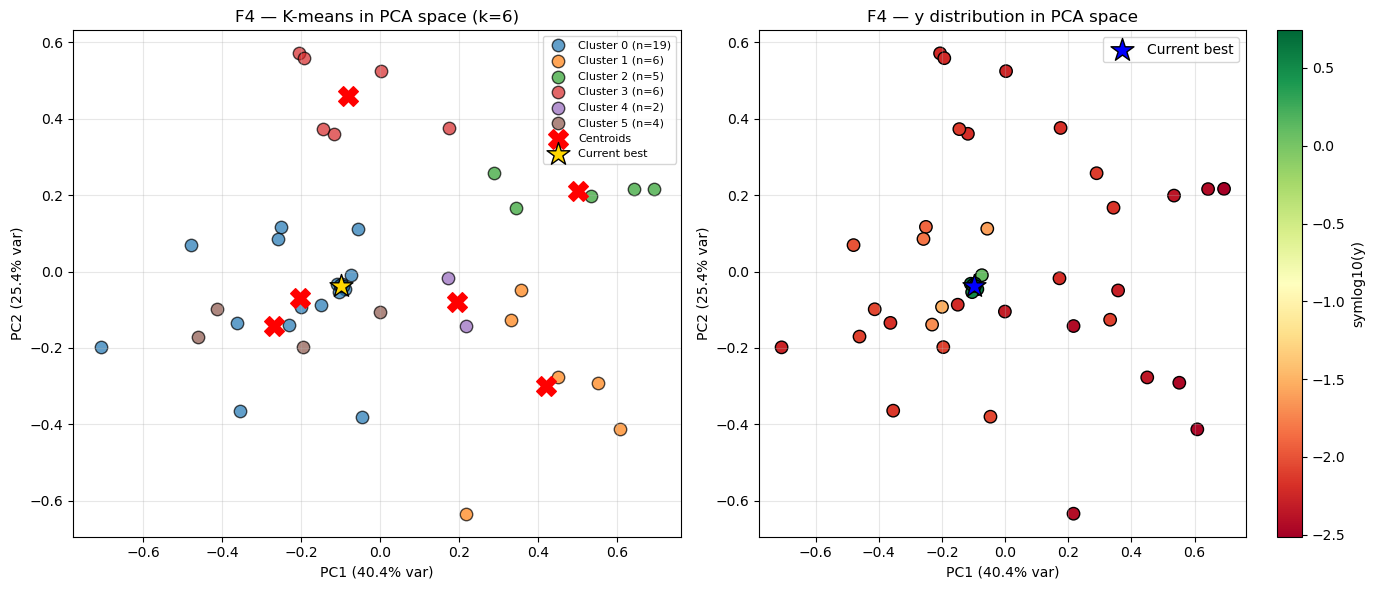

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(f"PCA explained variance: PC1 = {pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2 = {pca.explained_variance_ratio_[1]:.3f}")
print(f"Cumulative: {sum(pca.explained_variance_ratio_):.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: clusters in PCA space
for i in range(best_k):
    members = labels == i
    ax1.scatter(X_pca[members, 0], X_pca[members, 1],
                s=80, edgecolor='black', alpha=0.7,
                label=f'Cluster {i} (n={members.sum()})')
# Project centroids to PCA
centroids_pca = pca.transform(km.cluster_centers_)
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker='X', s=200, color='red', label='Centroids', zorder=5)
# Project current best
best_pca = pca.transform(X[y.argmax()].reshape(1, -1))[0]
ax1.scatter(*best_pca, marker='*', s=300, color='gold',
            edgecolor='black', label='Current best', zorder=6)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax1.set_title(f'F4 — K-means in PCA space (k={best_k})')
ax1.legend(loc='best', fontsize=8); ax1.grid(alpha=0.3)

# Right: PCA colored by symlog y
sc = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y_transformed,
                  cmap='RdYlGn', s=80, edgecolor='black')
plt.colorbar(sc, ax=ax2, label='symlog10(y)')
ax2.scatter(*best_pca, marker='*', s=300, color='blue',
            edgecolor='black', label='Current best')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax2.set_title('F4 — y distribution in PCA space')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('F4_clusters_pca.png', dpi=100, bbox_inches='tight')
plt.show()

##### Step 6 — Pairwise scatter (active dimensions: x1, x3, x4)

The GP identifies x1, x3, x4 as active and x2 as irrelevant. Pairwise 
scatter for the active dimensions reveals the peak structure directly.

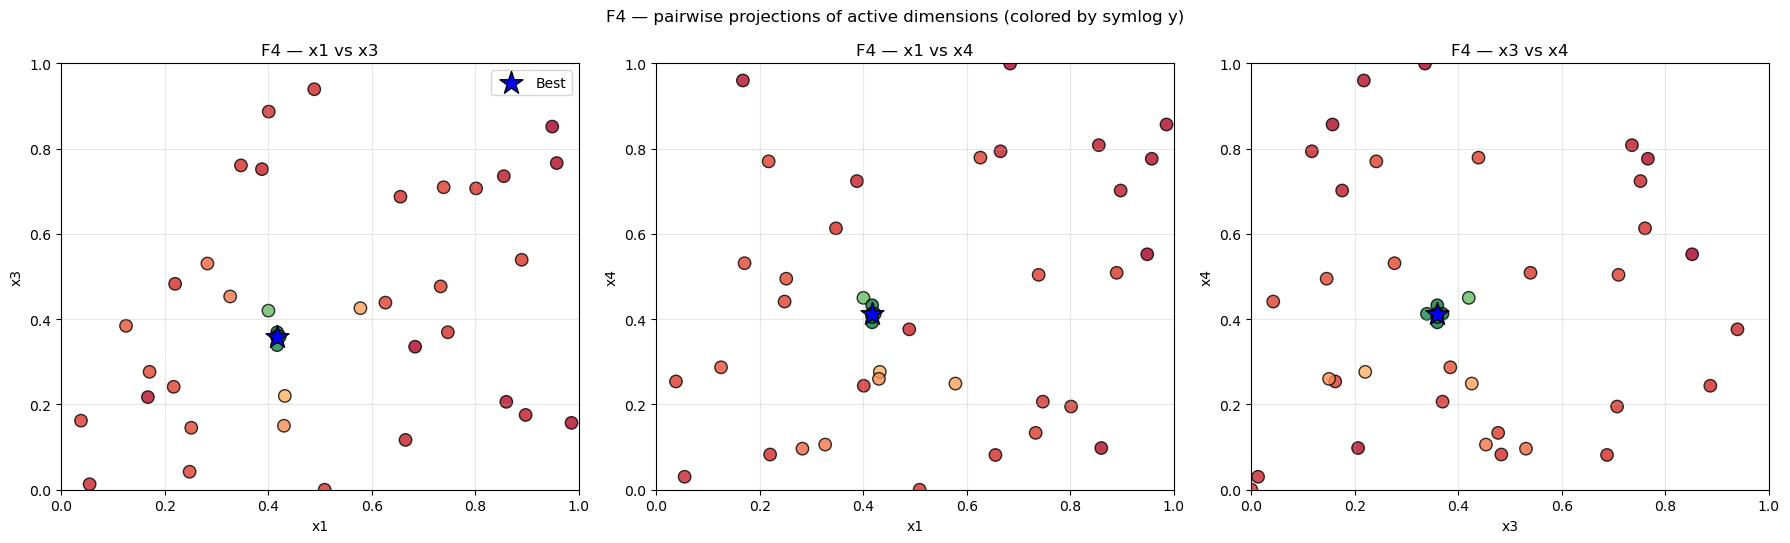

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
active_pairs = [(0, 2, 'x1', 'x3'), (0, 3, 'x1', 'x4'), (2, 3, 'x3', 'x4')]

for ax, (di, dj, di_lbl, dj_lbl) in zip(axes, active_pairs):
    # Color by symlog y
    sc = ax.scatter(X[:, di], X[:, dj], c=y_transformed,
                     cmap='RdYlGn', s=80, edgecolor='black', alpha=0.8)
    # Highlight current best
    ax.scatter(X[y.argmax(), di], X[y.argmax(), dj],
               marker='*', s=300, color='blue',
               edgecolor='black', label='Best', zorder=5)
    ax.set_xlabel(di_lbl); ax.set_ylabel(dj_lbl)
    ax.set_title(f'F4 — {di_lbl} vs {dj_lbl}')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    if ax is axes[0]:
        ax.legend()

plt.suptitle('F4 — pairwise projections of active dimensions (colored by symlog y)', fontsize=12)
plt.tight_layout()
plt.savefig('F4_pairwise.png', dpi=100, bbox_inches='tight')

##### Step 7 — Strategic implications

##### What clustering tells us about F4

1. **F4 has converged to a single tight high-y cluster** 
2. **The high-y sub-region is very narrow in all active dimensions** 
   (x1, x3, x4 spreads typically < 0.05) — F4 has a sharp, well-bracketed peak.
3. **GP says x2 is irrelevant** — broad spread in x2 within the high-y sub-region confirms this (any x2 value within ~0.3-0.5 produces similar y).
4. **The bottom-y points cluster in entirely different regions** of 
   PCA space — far from the high-y cluster.

### Reflection

**Past patterns**: F4 has been converged, the peak is genuinely tight.

**Clusters identified?**: Single dominant high-y cluster + multiple low-y exploration clusters. The structural signature is similar to F3: tight high-y region with broad low-y scatter, the GP's length-scale findings (x1, x3, x4 finite; x2 pinned) match the K-means cluster spread analysis.

**Model Effectiveness**: GP-EI on F4 has consistently recommended multi-dim moves with below-best predictions. Per-dim diagnostic + tight single-dim probes have been 
the only reliable strategy.

**Clustering parallel**: F4's optimization is effectively a finished K-means run — centroid has stabilized, remaining iterations only refine the cluster boundary characterization.

**Plotted trends**: F4's y-vs-round shows a jump from negative y to 0.74, followed by a flat plateau. The PCA 
scatter shows the dramatic separation between the high-y cluster and the low-y exploration points.